In [2]:
"""
算法：随机森林、XGBoost、LightGBM、逻辑回归
可视化：模型对比柱状图、ROC曲线、PR曲线、混淆矩阵、特征重要性
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# XGBoost 和 LightGBM (可选)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost 未安装，将跳过该模型")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM 未安装，将跳过该模型")

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ==================== 1. 数据加载与特征工程 ====================
def load_data(file_path):
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"数据集大小: {df.shape}")
    print(f"目标变量分布:\n{df['is_highly_cited'].value_counts()}")
    return df

def get_features(df):
    exclude = ['paper_id', 'title', 'abstract', 'doi', 'journal', 'authors', 'institutions',
               'countries', 'concepts', 'topics', 'title_clean', 'abstract_clean',
               'title_processed', 'abstract_processed', 'text_for_cluster', 'is_highly_cited',
               'cited_by_count', 'recent_citations', 'citation_percentile',
               'citation_density', 'citation_per_year', 'log_cited_by_count', 'log_recent_citations']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in exclude]
    print(f"使用特征数: {len(feature_cols)}")
    return df[feature_cols], df['is_highly_cited'], feature_cols

def preprocess(X_train, X_test):
    imp = SimpleImputer(strategy='median')
    X_train_imp = imp.fit_transform(X_train)
    X_test_imp = imp.transform(X_test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)
    return X_train_scaled, X_test_scaled, scaler, imp

def select_kbest(X_train, y_train, X_test, k=20):
    selector = SelectKBest(f_classif, k=min(k, X_train.shape[1]))
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)
    return X_train_sel, X_test_sel, selector

# ==================== 2. 阈值优化（最大化 F1，不绘图） ====================
def optimal_threshold_f1(model, X_val, y_val):
    y_proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]

def train_and_eval(model, name, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    thresh = optimal_threshold_f1(model, X_val, y_val)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    print(f"\n========== {name} ==========")
    print(f"最优阈值: {thresh:.4f}")
    print(f"精确率: {prec:.4f} | 召回率: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}")
    return {'name': name, 'proba': y_proba, 'y_pred': y_pred, 'y_true': y_test,
            'model': model, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc_score}

In [6]:
# ==================== 3. 可视化（保留必要图表） ====================
def plot_model_comparison(results):
    names = [r['name'] for r in results]
    precisions = [r['precision'] for r in results]
    recalls = [r['recall'] for r in results]
    f1s = [r['f1'] for r in results]
    aucs = [r['auc'] for r in results]
    
    x = np.arange(len(names))
    width = 0.2
    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(x - 1.5*width, precisions, width, label='精确率', color='steelblue')
    ax.bar(x - 0.5*width, recalls, width, label='召回率', color='orange')
    ax.bar(x + 0.5*width, f1s, width, label='F1分数', color='green')
    ax.bar(x + 1.5*width, aucs, width, label='AUC', color='red')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('分数')
    ax.set_title('模型性能对比')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150)
    plt.show()

def plot_roc_curves(results):
    plt.figure(figsize=(8,6))
    for r in results:
        fpr, tpr, _ = roc_curve(r['y_true'], r['proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{r['name']} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('假正率')
    plt.ylabel('真正率')
    plt.title('ROC曲线对比')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig('roc_curves.png', dpi=150)
    plt.show()

def plot_pr_curves(results):
    plt.figure(figsize=(8,6))
    for r in results:
        precisions, recalls, _ = precision_recall_curve(r['y_true'], r['proba'])
        plt.plot(recalls, precisions, lw=2, label=r['name'])
    plt.xlabel('召回率')
    plt.ylabel('精确率')
    plt.title('PR曲线对比')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.savefig('pr_curves.png', dpi=150)
    plt.show()

def plot_confusion_matrix(result, name):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['非高被引','高被引'], yticklabels=['非高被引','高被引'])
    axes[0].set_title(f'{name} 混淆矩阵 (计数)')
    axes[0].set_ylabel('真实')
    axes[0].set_xlabel('预测')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=['非高被引','高被引'], yticklabels=['非高被引','高被引'])
    axes[1].set_title(f'{name} 混淆矩阵 (归一化)')
    axes[1].set_ylabel('真实')
    axes[1].set_xlabel('预测')
    plt.tight_layout()
    plt.savefig(f'cm_{name.lower()}.png', dpi=150)
    plt.show()

def plot_feature_importance(model, feature_names, selector, top=15):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        mask = selector.get_support()
        names = [f for i, f in enumerate(feature_names) if mask[i]]
        idx = np.argsort(imp)[-top:][::-1]
        plt.figure(figsize=(10,6))
        plt.barh(range(len(idx)), imp[idx], color='steelblue')
        plt.yticks(range(len(idx)), [names[i] for i in idx])
        plt.xlabel('重要性')
        plt.title(f'特征重要性 (随机森林)')
        for i, v in enumerate(imp[idx]):
            plt.text(v + 0.002, i, f'{v:.3f}', va='center')
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=150)
        plt.show()
    else:
        print("当前模型无 feature_importances_ 属性，跳过特征重要性图")

数据集大小: (6551, 43)
目标变量分布:
is_highly_cited
0    5773
1     778
Name: count, dtype: int64
使用特征数: 20
训练集: 3930, 验证集: 1310, 测试集: 1311

应用 SMOTE 过采样...
过采样后训练集大小: 6926

========== RandomForest ==========
最优阈值: 0.6502
精确率: 0.4366 | 召回率: 0.5962 | F1: 0.5041 | AUC: 0.8877


C:\Users\fsxqc\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [22:27:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



========== XGBoost ==========
最优阈值: 0.3784
精确率: 0.3867 | 召回率: 0.6346 | F1: 0.4806 | AUC: 0.8824


C:\Users\fsxqc\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\fsxqc\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



========== LightGBM ==========
最优阈值: 0.2556
精确率: 0.3824 | 召回率: 0.7821 | F1: 0.5137 | AUC: 0.8804

========== LogisticRegression ==========
最优阈值: 0.8022
精确率: 0.5000 | 召回率: 0.5000 | F1: 0.5000 | AUC: 0.8923


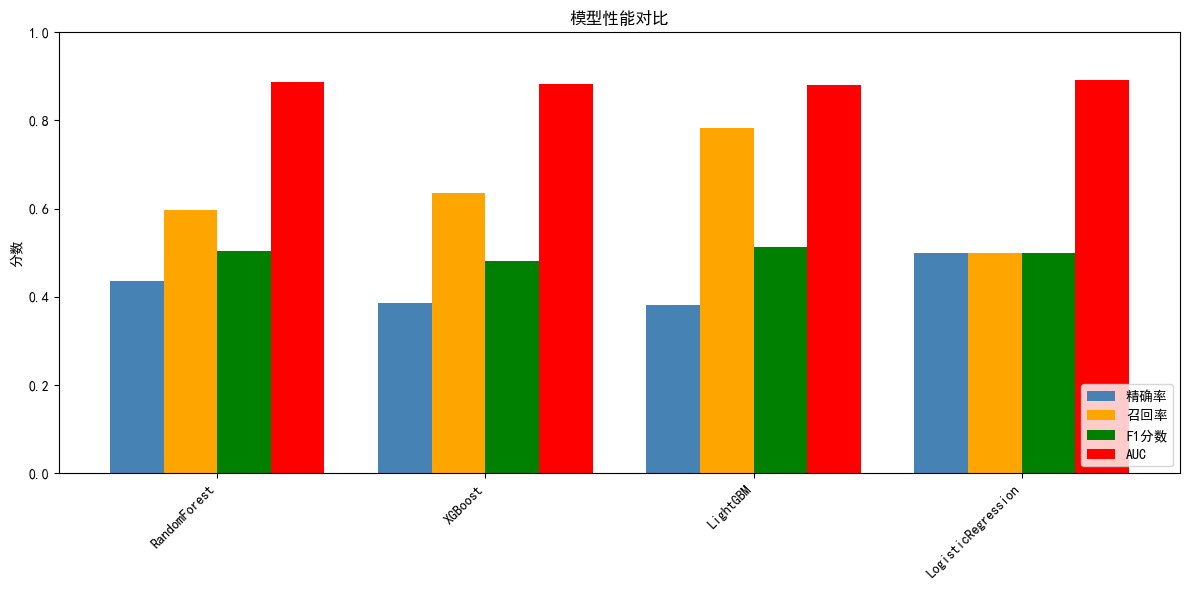

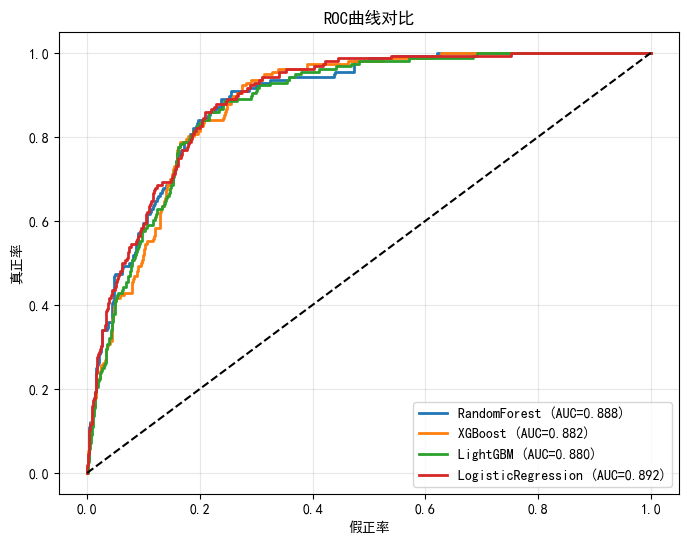

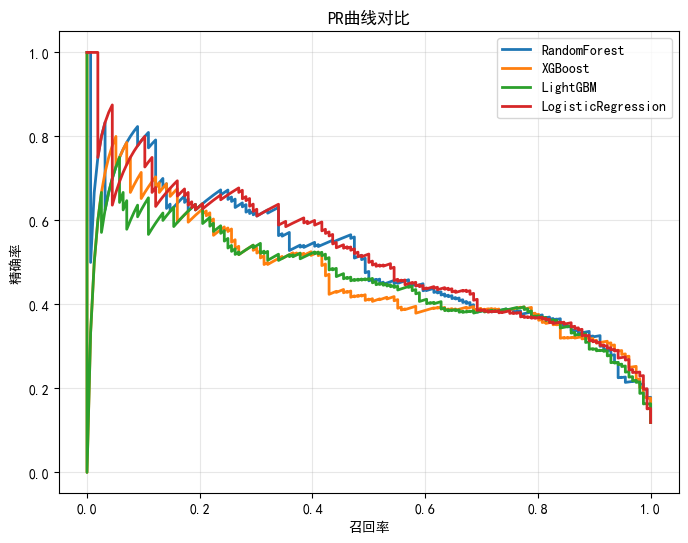

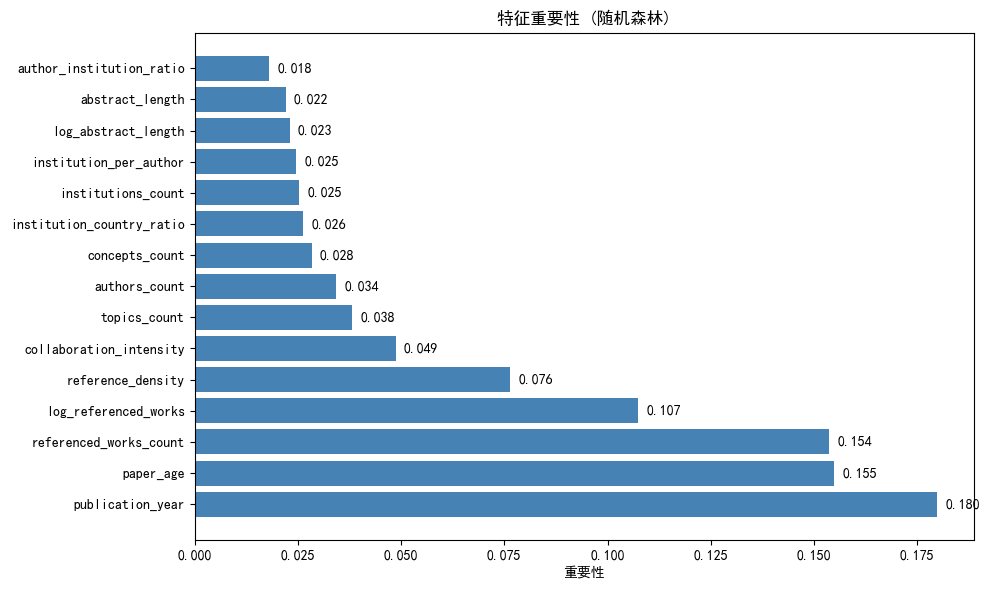

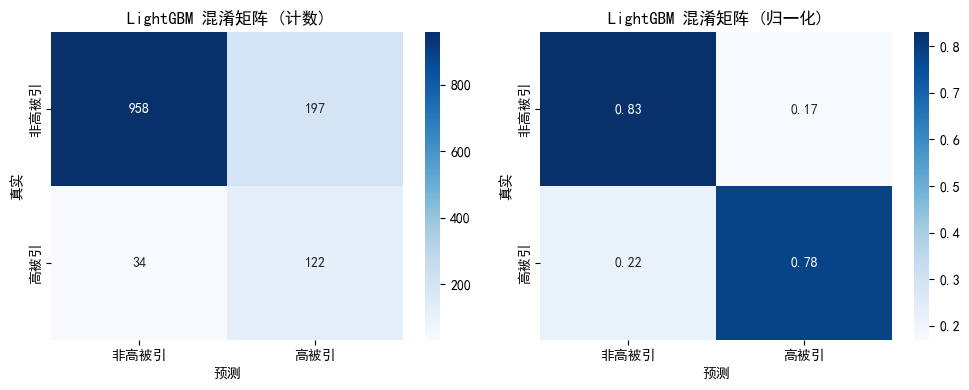


最佳模型: LightGBM | 精确率=0.3824 召回率=0.7821 F1=0.5137 AUC=0.8804


In [8]:
# ==================== 主程序 ====================
def main():
    df = load_data("ADHD_特征工程后数据.csv")
    X, y, feature_names = get_features(df)
    
    # 划分训练集(60%)、验证集(20%)、测试集(20%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    print(f"训练集: {X_train.shape[0]}, 验证集: {X_val.shape[0]}, 测试集: {X_test.shape[0]}")
    
    # 预处理
    X_train_scaled, X_val_scaled, scaler, imp = preprocess(X_train, X_val)
    X_test_scaled = scaler.transform(imp.transform(X_test))
    
    # 特征选择
    X_train_sel, X_val_sel, selector = select_kbest(X_train_scaled, y_train, X_val_scaled, k=20)
    X_test_sel = selector.transform(X_test_scaled)
    
    # SMOTE 过采样
    print("\n应用 SMOTE 过采样...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)
    print(f"过采样后训练集大小: {X_train_res.shape[0]}")
    
    # 定义模型（无神经网络）
    models = {}
    models['RandomForest'] = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
    if XGB_AVAILABLE:
        models['XGBoost'] = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='logloss')
    if LGB_AVAILABLE:
        models['LightGBM'] = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, class_weight='balanced', random_state=42, verbose=-1)
    models['LogisticRegression'] = LogisticRegression(class_weight='balanced', random_state=42, C=0.1, max_iter=1000)
    
    results = []
    for name, model in models.items():
        if name == 'XGBoost' and XGB_AVAILABLE:
            scale = len(y_train_res[y_train_res==0]) / len(y_train_res[y_train_res==1])
            model.set_params(scale_pos_weight=scale)
        res = train_and_eval(model, name, X_train_res, y_train_res, X_val_sel, y_val, X_test_sel, y_test)
        results.append(res)
    
    # 可视化
    plot_model_comparison(results)
    plot_roc_curves(results)
    plot_pr_curves(results)
    
    # 特征重要性（以随机森林为例）
    if 'RandomForest' in models:
        rf_model = models['RandomForest']
        rf_model.fit(X_train_res, y_train_res)
        plot_feature_importance(rf_model, feature_names, selector, top=15)
    
    # 最佳模型混淆矩阵
    best = max(results, key=lambda x: x['f1'])
    plot_confusion_matrix(best, best['name'])
    
    print(f"\n最佳模型: {best['name']} | 精确率={best['precision']:.4f} 召回率={best['recall']:.4f} F1={best['f1']:.4f} AUC={best['auc']:.4f}")

if __name__ == "__main__":
    main()